# About the project

We apply *"Data quality"*, whose **main goal** is the fitness of **data** for use in a **specific purpose**.

In this case, that purpose is **clinical trial analysis** and **pharmaceutical consulting**.

Therefore, a **data point** is considered **valid** and of **quality** if and only if it allows **correct decisions** to be made about **clinical trials**.

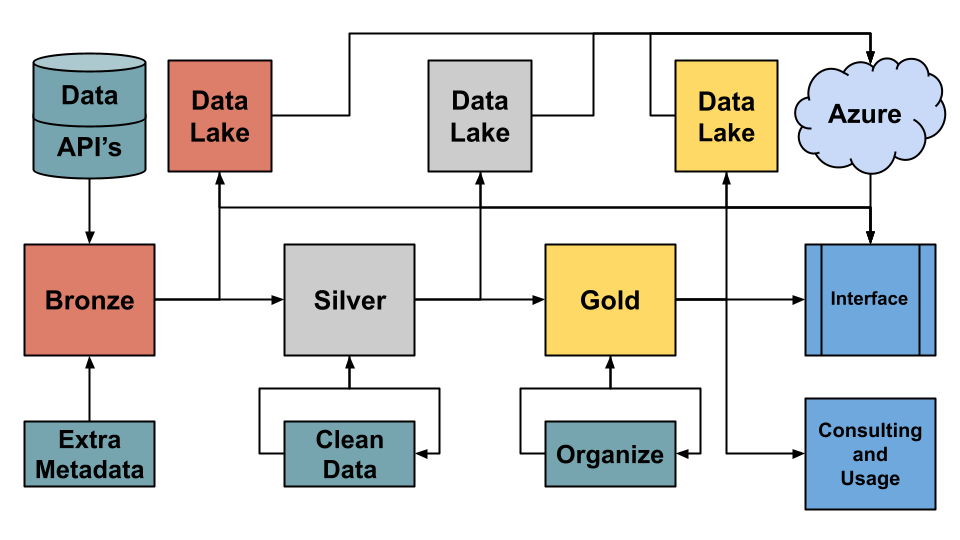

# Pre-system

In [9]:

# ============================================================
# CENTRAL CONFIGURATION + LOGGING (Incremental + Multi-source)
# ============================================================

import os
import logging
from datetime import datetime
import uuid

# ---------- Base paths ----------
# Local data folder inside the repo: Medallion_life_science/data
# (run the notebook with cwd = Medallion_life_science)
DATA_ROOT = os.path.join(os.getcwd(), "data")

# ---------- Configuration ----------
CONFIG = {
    # ClinicalTrials paths
    "bronze_path": f"{DATA_ROOT}/bronze/clinical_trials_raw",
    "silver_path": f"{DATA_ROOT}/silver/studies",
    "silver_quarantine_path": f"{DATA_ROOT}/silver/quarantine_studies",

    # OpenFDA paths (new source)
    "bronze_openfda_path": f"{DATA_ROOT}/bronze/openfda_drug_events",
    "silver_openfda_path": f"{DATA_ROOT}/silver/drug_events",
    "silver_openfda_quarantine_path": f"{DATA_ROOT}/silver/quarantine_drug_events",

    # Gold
    "gold_base_path": f"{DATA_ROOT}/gold",

    # Watermarks
    "watermark_path": f"{DATA_ROOT}/control/watermarks",

    # ClinicalTrials parameters
    "max_studies": 300,
    "page_size": 50,
    "api_base_url": "https://clinicaltrials.gov/api/v2/studies",
    "source_name": "clinicaltrials_api_v2",

    # OpenFDA parameters
    "openfda_base_url": "https://api.fda.gov/drug/event.json",
    "openfda_limit": 100,          # max per page
    "openfda_max_records": 500,    # total to download in this demo
}

# Create local data folders if they don't exist (Bronze/Silver/Gold/control)
for _subdir in ["bronze", "silver", "gold", "control"]:
    os.makedirs(os.path.join(DATA_ROOT, _subdir), exist_ok=True)

# ---------- Logging ----------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger("clinical_trials_pipeline")

logger.info("Configuration loaded successfully")
print("✅ Configuration and logging ready (Incremental + OpenFDA)")
print(f"📁 Local data at: {DATA_ROOT}")

2026-10-04 11:04:15 | INFO | Configuration loaded successfully


✅ Configuration and logging ready (Incremental + OpenFDA)
📁 Local data at: /home/arianpalace/Git/Medallion_life_science/data


In [10]:
# ============================================================
# STRUCTURED ERROR HANDLING (per-stage execution auditing)
# ============================================================

import traceback
from contextlib import contextmanager

@contextmanager
def run_stage(stage_name: str):
    """Wraps a pipeline stage (fetch/bronze/silver/gold) with
    start/success/duration/failure logging for end-to-end traceability."""
    start = datetime.utcnow()
    logger.info(f"▶ START stage '{stage_name}'")
    try:
        yield
        duration = (datetime.utcnow() - start).total_seconds()
        logger.info(f"✅ SUCCESS stage '{stage_name}' ({duration:.2f}s)")
    except Exception as e:
        duration = (datetime.utcnow() - start).total_seconds()
        logger.error(f"❌ FAILURE stage '{stage_name}' after {duration:.2f}s: {e}")
        logger.error(traceback.format_exc())
        print(f"❌ ERROR in stage '{stage_name}': {e}")
        raise

print("✅ 'run_stage' helper ready to audit pipeline stages")


✅ 'run_stage' helper ready to audit pipeline stages


In [11]:
# ============================================================
# WATERMARK FUNCTIONS (Incremental)
# ============================================================

from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType

def get_watermark(source_name: str):
    """Reads the latest watermark for a source. Returns None if it doesn't exist."""
    try:
        df = spark.read.format("delta").load(CONFIG["watermark_path"])
        row = df.filter(F.col("source") == source_name).orderBy(F.desc("updated_at")).limit(1).collect()
        if row:
            return row[0]["watermark_value"]
        return None
    except Exception:
        return None


def update_watermark(source_name: str, watermark_value: str):
    """Updates (or inserts) the watermark for a source."""
    now = datetime.utcnow().isoformat()

    data = [Row(source=source_name, watermark_value=watermark_value, updated_at=now)]
    schema = StructType([
        StructField("source", StringType(), False),
        StructField("watermark_value", StringType(), False),
        StructField("updated_at", StringType(), False)
    ])
    df_new = spark.createDataFrame(data, schema)

    # Write in append mode (we can deduplicate later if needed)
    df_new.write \
        .format("delta") \
        .mode("append") \
        .option("mergeSchema", "true") \
        .save(CONFIG["watermark_path"])

    logger.info(f"Watermark updated → {source_name}: {watermark_value}")
    print(f"✅ Watermark updated → {source_name}: {watermark_value}")


# Bronze (Raw and register)

Be the immutable source of truth for what arrived from the outside world.

It's not transformed. It's not interpreted. It's only recorded.

What's applied:
- Ingesting data in its original format (nested JSON in your case).
- Adding audit metadata (*_ingested_at*, *_source*, *_pipeline_run_id*).
- Writing in a format that supports history (Delta Lake).
- Write strategy: usually append-only.

The payload is stored almost intact + technical control columns.

This layer is based on the *“Write Audit Publish”* principle and the idea of immutability of evidence.

In modern data engineering it's considered that:

*"Raw data is evidence. Transformations are interpretations."*

If you transform too early, you lose the ability to:

- Reprocess with new logic.
- Audit.
- Recover from transformation errors.
- Comply with traceability (very important in pharma).

Theoretical foundation:

- Event Sourcing / Append-only log: similar to storing the event log instead of the final state.
- Data Lineage: Bronze is the origin of all lineage.
- Schema-on-Read vs Schema-on-Write: Bronze prefers Schema-on-Read (the schema is interpreted later).

Assuming that:

$B_t = D_{raw} \cup M_t$

- Let $D_{raw}$ be the set of data received at instant $t$.
- Let $M_t$ be the audit metadata we add to the system.

The key property is **monotonicity**:

$B_{t} \subseteq B_{t+1}$

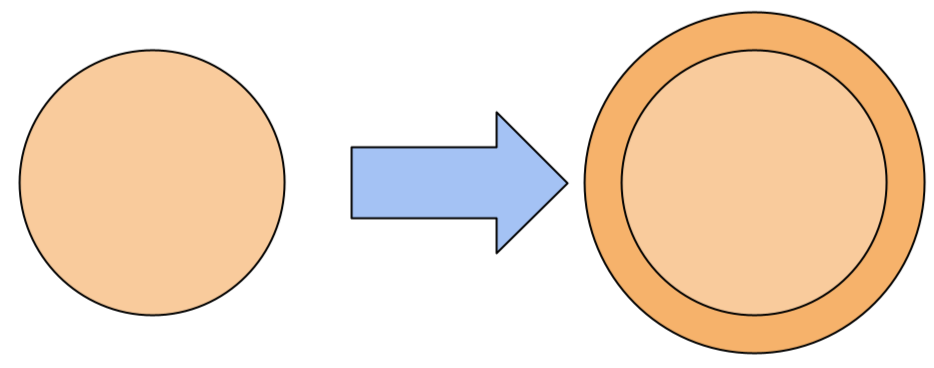

(only appends, past data is never modified or deleted).

Sources:
- [clinicaltrials](https://clinicaltrials.gov/search?viewType=Card)

In [12]:
!pip install pyspark==3.5.1 delta-spark==3.2.0

IOStream.flush timed out


In [13]:
# ============================================================
# SETUP SPARK + DELTA LAKE
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from delta import configure_spark_with_delta_pip

builder = SparkSession.builder \
    .appName("PharmaBronzeIngestion") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.2.0")

spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel("WARN")

print("✅ Spark + Delta Lake ready")
print(f"Spark version: {spark.version}")

✅ Spark + Delta Lake ready
Spark version: 3.5.1


In [14]:
# ============================================================
# ROBUST INGESTION FUNCTION (WITH RETRIES)
# ============================================================

import requests
import time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

def create_session_with_retries(retries=3, backoff_factor=1.0):
    session = requests.Session()
    retry_strategy = Retry(
        total=retries,
        backoff_factor=backoff_factor,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"]
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    return session


def fetch_clinical_trials(max_studies: int = 200, page_size: int = 50):
    """
    Downloads studies from the ClinicalTrials.gov API v2 with retries and logging.
    """
    session = create_session_with_retries()
    all_studies = []
    page_token = None
    fetched = 0

    logger.info(f"Starting download. Target: {max_studies} studies")

    while fetched < max_studies:
        params = {
            "pageSize": min(page_size, max_studies - fetched),
            "format": "json"
        }
        if page_token:
            params["pageToken"] = page_token

        try:
            response = session.get(CONFIG["api_base_url"], params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
        except requests.exceptions.RequestException as e:
            logger.error(f"Error calling the API: {e}")
            raise

        studies = data.get("studies", [])
        if not studies:
            logger.warning("No more studies received. Finishing.")
            break

        all_studies.extend(studies)
        fetched += len(studies)
        page_token = data.get("nextPageToken")

        logger.info(f"Downloaded: {fetched} studies...")

        if not page_token:
            break

        time.sleep(0.3)  # Basic rate-limit courtesy to the API

    logger.info(f"Download finished. Total: {len(all_studies)} studies")
    return all_studies

In [15]:
# ============================================================
# BRONZE ClinicalTrials – Incremental Download
# ============================================================

# Read watermark (last processed update date)
last_watermark = get_watermark("clinicaltrials")
print(f"Last watermark: {last_watermark}")

def fetch_clinical_trials_incremental(max_studies=300, page_size=50, last_update_from=None):
    """
    Incremental version.
    If last_update_from is passed (format YYYY-MM-DD), tries to filter by lastUpdatePostDate.
    Note: the public ClinicalTrials API has filtering limitations,
    so we combine it with watermark + later deduplication.
    """
    session = create_session_with_retries()
    all_studies = []
    page_token = None
    fetched = 0

    logger.info(f"Starting incremental download. Target: {max_studies}")

    while fetched < max_studies:
        params = {
            "pageSize": min(page_size, max_studies - fetched),
            "format": "json",
            "sort": "LastUpdatePostDate:desc"   # most recent first
        }

        # Approximate date filter (if the API supports it at this time)
        if last_update_from:
            params["filter.advanced"] = f"AREA[LastUpdatePostDate]RANGE[{last_update_from}, MAX]"

        if page_token:
            params["pageToken"] = page_token

        try:
            response = session.get(CONFIG["api_base_url"], params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
        except Exception as e:
            logger.error(f"API error: {e}")
            raise

        studies = data.get("studies", [])
        if not studies:
            break

        all_studies.extend(studies)
        fetched += len(studies)
        page_token = data.get("nextPageToken")

        logger.info(f"Downloaded: {fetched}")

        if not page_token:
            break
        time.sleep(0.3)

    return all_studies


# Run download
raw_studies = fetch_clinical_trials_incremental(
    max_studies=CONFIG["max_studies"],
    page_size=CONFIG["page_size"],
    last_update_from=last_watermark
)
print(f"✅ Studies downloaded in this run: {len(raw_studies)}")


2026-10-04 11:04:26 | INFO | Error while sending or receiving.
Traceback (most recent call last):
  File "/home/arianpalace/Git/Medallion_life_science/.venv/lib/python3.12/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer
2026-10-04 11:04:26 | INFO | Closing down clientserver connection
2026-10-04 11:04:26 | INFO | Exception while sending command.
Traceback (most recent call last):
  File "/home/arianpalace/Git/Medallion_life_science/.venv/lib/python3.12/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/arianpalace/Git/Medallion_life_science/.venv/lib/python3.12/site-packages/py4j/java_gateway.py", line 1038, in send_command
    re

Last watermark: None


2026-10-04 11:04:27 | INFO | Downloaded: 50
2026-10-04 11:04:27 | INFO | Downloaded: 100
2026-10-04 11:04:28 | INFO | Downloaded: 150
2026-10-04 11:04:28 | INFO | Downloaded: 200
2026-10-04 11:04:29 | INFO | Downloaded: 250
2026-10-04 11:04:29 | INFO | Downloaded: 300


✅ Studies downloaded in this run: 300


In [16]:
# ============================================================
# BRONZE ClinicalTrials – Save with incremental logic
# ============================================================

import json
from delta.tables import DeltaTable
from pyspark.sql.utils import AnalysisException

run_id = str(uuid.uuid4())
ingested_at = datetime.utcnow().isoformat()

# Nothing new fetched (e.g. watermark filter matched no studies) -> skip save safely
if not raw_studies:
    print("⚠ No new studies to ingest in this run. Skipping Bronze save.")
else:
    rdd = spark.sparkContext.parallelize([json.dumps(s) for s in raw_studies])
    df_raw = spark.read.json(rdd)

    if "protocolSection" not in df_raw.columns:
        raise ValueError(
            "Downloaded studies don't contain 'protocolSection'. "
            "Check the ClinicalTrials.gov API response shape."
        )

    df_bronze_new = df_raw \
        .withColumn("_ingested_at", F.lit(ingested_at)) \
        .withColumn("_source", F.lit(CONFIG["source_name"])) \
        .withColumn("_pipeline_run_id", F.lit(run_id)) \
        .withColumn("_ingestion_date", F.current_date()) \
        .withColumn("_ingestion_year", F.year(F.current_date())) \
        .withColumn("_ingestion_month", F.month(F.current_date()))

    # Extract nct_id so we can MERGE
    df_bronze_new = df_bronze_new.withColumn(
        "nct_id_temp",
        F.col("protocolSection.identificationModule.nctId")
    )

    print(f"New records to process: {df_bronze_new.count()}")

    with run_stage("bronze_save_clinicaltrials"):
        try:
            delta_bronze = DeltaTable.forPath(spark, CONFIG["bronze_path"])

            # MERGE: update if nct_id already exists, insert otherwise
            delta_bronze.alias("old") \
                .merge(
                    df_bronze_new.alias("new"),
                    "old.protocolSection.identificationModule.nctId = new.nct_id_temp"
                ) \
                .whenMatchedUpdateAll() \
                .whenNotMatchedInsertAll() \
                .execute()

            logger.info("✅ Bronze MERGE completed (incremental)")
            print("✅ Bronze MERGE completed (incremental)")

        except Exception as e:
            # First run (table doesn't exist yet) → overwrite; any other
            # real error is re-raised and logged by run_stage.
            if not isinstance(e, AnalysisException):
                raise
            print(f"First load or table doesn't exist ({e}). Overwriting...")
            df_bronze_new.drop("nct_id_temp").write \
                .format("delta") \
                .mode("overwrite") \
                .option("overwriteSchema", "true") \
                .partitionBy("_ingestion_date") \
                .save(CONFIG["bronze_path"])
            logger.info(f"✅ Bronze saved at: {CONFIG['bronze_path']}")
            print("✅ Bronze created for the first time")

# Update watermark with today's date
today_str = datetime.utcnow().strftime("%Y-%m-%d")
update_watermark("clinicaltrials", today_str)


/tmp/ipykernel_12528/270726726.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ingested_at = datetime.utcnow().isoformat()
/tmp/ipykernel_12528/2707875938.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  start = datetime.utcnow()
2026-10-04 11:04:31 | INFO | ▶ START stage 'bronze_save_clinicaltrials'


New records to process: 300
First load or table doesn't exist ([DELTA_MISSING_DELTA_TABLE] `/home/arianpalace/Git/Medallion_life_science/data/bronze/clinical_trials_raw` is not a Delta table.). Overwriting...


26/10/04 11:04:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/10/04 11:04:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/10/04 11:04:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/10/04 11:04:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/10/04 11:04:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/10/04 11:04:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/10/04 11:04:33 WARN MemoryManager: Total allocation exceeds 95.

✅ Bronze created for the first time


2026-10-04 11:04:35 | INFO | Watermark updated → clinicaltrials: 2026-10-04


✅ Watermark updated → clinicaltrials: 2026-10-04


In [17]:
# ============================================================
# BRONZE VERIFICATION
# ============================================================

df_check = spark.read.format("delta").load(CONFIG["bronze_path"])

print("=== BRONZE VERIFICATION ===")
print(f"Total records: {df_check.count()}")

print("\nAudit columns:")
df_check.select(
    "_ingested_at", "_source", "_pipeline_run_id", "_ingestion_date"
).show(5, truncate=False)

print("\nAvailable partitions:")
df_check.select("_ingestion_date").distinct().orderBy("_ingestion_date").show()

print("\nSchema (first columns):")
df_check.printSchema()

=== BRONZE VERIFICATION ===
Total records: 300

Audit columns:
+--------------------------+---------------------+------------------------------------+---------------+
|_ingested_at              |_source              |_pipeline_run_id                    |_ingestion_date|
+--------------------------+---------------------+------------------------------------+---------------+
|2026-10-04T09:04:30.244510|clinicaltrials_api_v2|45a39141-7769-4145-b7fa-4816b3b0e35e|2026-10-04     |
|2026-10-04T09:04:30.244510|clinicaltrials_api_v2|45a39141-7769-4145-b7fa-4816b3b0e35e|2026-10-04     |
|2026-10-04T09:04:30.244510|clinicaltrials_api_v2|45a39141-7769-4145-b7fa-4816b3b0e35e|2026-10-04     |
|2026-10-04T09:04:30.244510|clinicaltrials_api_v2|45a39141-7769-4145-b7fa-4816b3b0e35e|2026-10-04     |
|2026-10-04T09:04:30.244510|clinicaltrials_api_v2|45a39141-7769-4145-b7fa-4816b3b0e35e|2026-10-04     |
+--------------------------+---------------------+------------------------------------+---------------+
o

# Silver (Cleaned)

Turn raw, heterogeneous data into **reliable**, **typed**, and **standardized data**, ready to be used by *multiple consumers*.

But the main point is that the data must be reproducible for any team that wants to use it (since they could otherwise apply different ways of cleaning the data).

---

**Theoretical foundations (Data Quality Theory)**:
- **Completeness**: % of non-null values.
- **Uniqueness**: Absence of duplicates.
- **Validity**: Meets the allowed domain.
- **Consistency**: Coherence between fields.
- **Accuracy**: Close to reality.
- **Timeliness**: Freshness of the data.

Assuming $Q(r)$ is the boolean verification function that accepts records $(r)$ as an argument, satisfying:

$Q(r) =
\begin{cases}
1 & \text{if record } r \text{ meets all rules} \\
0 & \text{otherwise}
\end{cases}$

We can compute the quality % (those that satisfy $Q(r)$) by averaging the results across all records:

$\text{Data Quality Score} = \frac{1}{N} \sum_{i=1}^{N} Q(r_i)$

Applying this logic to our data, we get what we're looking for in the Silver record:
Theoretical foundations (Data Quality Theory):
- **Completeness**: `nct_id` not null.
- **Uniqueness**: A single record per `nct_id`.
- **Validity**: `overall_status` ∈ known list (**sources**).
- **Consistency**: `completion_date ≥ start_date`.
- **Accuracy**: Requires extra domain knowledge to validate.
- **Timeliness**: `_ingested_at` added earlier.

---

**Theoretical foundations (Deduplication)**:

Based on defining a business key. In this case, we can use our unique identity field for each record:

$\text{Business Key} = nct\_id$

A *conflict resolution* function is applied (usually *“keep the most recent”*).

---

**Theoretical foundations (Value normalization)**:

Closes in on the idea of *canonical representation*:

$f: \text{Dirty value} \rightarrow \text{Canonical value}$

E.g.: $f: \text{("Completed", "completed", "COMPLETED")} \rightarrow \text{"COMPLETED"}$

In [18]:
# ============================================================
# SILVER - Read Bronze + Extract fields
# ============================================================

from pyspark.sql import functions as F

df_bronze = spark.read.format("delta").load(CONFIG["bronze_path"])
logger.info(f"Records read from Bronze: {df_bronze.count()}")
print(f"Records in Bronze: {df_bronze.count()}")

# Some fields (e.g. lastKnownStatus) only appear in certain studies;
# validated against the actual schema to avoid FIELD_NOT_FOUND.
def safe_nested_col(schema, dotted_path: str, alias: str):
    parts = dotted_path.split(".")
    current = schema
    for part in parts:
        if not hasattr(current, "fields"):
            return F.lit(None).alias(alias)
        field_names = [f.name for f in current.fields]
        if part not in field_names:
            return F.lit(None).alias(alias)
        current = current[part].dataType
    return F.col(dotted_path).alias(alias)

df_silver = df_bronze.select(
    # Identification
    F.col("protocolSection.identificationModule.nctId").alias("nct_id"),
    F.col("protocolSection.identificationModule.briefTitle").alias("brief_title"),
    F.col("protocolSection.identificationModule.officialTitle").alias("official_title"),
    F.col("protocolSection.identificationModule.acronym").alias("acronym"),

    # Status and dates
    F.col("protocolSection.statusModule.overallStatus").alias("overall_status"),
    safe_nested_col(df_bronze.schema, "protocolSection.statusModule.lastKnownStatus", "last_known_status"),
    F.col("protocolSection.statusModule.startDateStruct.date").alias("start_date"),
    F.col("protocolSection.statusModule.completionDateStruct.date").alias("completion_date"),
    F.col("protocolSection.statusModule.primaryCompletionDateStruct.date").alias("primary_completion_date"),
    F.col("protocolSection.statusModule.whyStopped").alias("why_stopped"),

    # Study design
    F.col("protocolSection.designModule.studyType").alias("study_type"),
    F.col("protocolSection.designModule.phases").alias("phases"),
    F.col("protocolSection.designModule.enrollmentInfo.count").alias("enrollment_count"),
    F.col("protocolSection.designModule.enrollmentInfo.type").alias("enrollment_type"),
    F.col("protocolSection.designModule.designInfo.allocation").alias("allocation"),
    F.col("protocolSection.designModule.designInfo.interventionModel").alias("intervention_model"),
    F.col("protocolSection.designModule.designInfo.primaryPurpose").alias("primary_purpose"),
    F.col("protocolSection.designModule.designInfo.maskingInfo.masking").alias("masking"),

    # Sponsor
    F.col("protocolSection.sponsorCollaboratorsModule.leadSponsor.name").alias("lead_sponsor_name"),
    F.col("protocolSection.sponsorCollaboratorsModule.leadSponsor.class").alias("lead_sponsor_class"),

    # Conditions and keywords
    F.col("protocolSection.conditionsModule.conditions").alias("conditions"),
    F.col("protocolSection.conditionsModule.keywords").alias("keywords"),

    # Results and description
    F.col("hasResults").alias("has_results"),
    F.col("protocolSection.descriptionModule.briefSummary").alias("brief_summary"),

    # Audit (kept from Bronze)
    F.col("_ingested_at"),
    F.col("_source"),
    F.col("_pipeline_run_id"),
    F.col("_ingestion_date")
)

print("✅ Fields extracted")
df_silver.printSchema()

2026-10-04 11:04:38 | INFO | Records read from Bronze: 300


Records in Bronze: 300
✅ Fields extracted
root
 |-- nct_id: string (nullable = true)
 |-- brief_title: string (nullable = true)
 |-- official_title: string (nullable = true)
 |-- acronym: string (nullable = true)
 |-- overall_status: string (nullable = true)
 |-- last_known_status: void (nullable = true)
 |-- start_date: string (nullable = true)
 |-- completion_date: string (nullable = true)
 |-- primary_completion_date: string (nullable = true)
 |-- why_stopped: string (nullable = true)
 |-- study_type: string (nullable = true)
 |-- phases: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- enrollment_count: long (nullable = true)
 |-- enrollment_type: string (nullable = true)
 |-- allocation: string (nullable = true)
 |-- intervention_model: string (nullable = true)
 |-- primary_purpose: string (nullable = true)
 |-- masking: string (nullable = true)
 |-- lead_sponsor_name: string (nullable = true)
 |-- lead_sponsor_class: string (nullable = true)
 |-- condi

In [19]:
# ============================================================
# SILVER - Cleaning and typing
# ============================================================

df_silver_clean = df_silver \
    .withColumn("nct_id", F.trim(F.col("nct_id"))) \
    .withColumn("brief_title", F.trim(F.col("brief_title"))) \
    .withColumn("official_title", F.trim(F.col("official_title"))) \
    .withColumn("acronym", F.trim(F.col("acronym"))) \
    .withColumn("overall_status", F.upper(F.trim(F.col("overall_status")))) \
    .withColumn("last_known_status", F.upper(F.trim(F.col("last_known_status")))) \
    .withColumn("study_type", F.upper(F.trim(F.col("study_type")))) \
    .withColumn("lead_sponsor_name", F.trim(F.col("lead_sponsor_name"))) \
    .withColumn("lead_sponsor_class", F.upper(F.trim(F.col("lead_sponsor_class")))) \
    .withColumn("enrollment_type", F.upper(F.trim(F.col("enrollment_type")))) \
    \
    .withColumn("enrollment_count", F.col("enrollment_count").cast("long")) \
    .withColumn("has_results", F.col("has_results").cast("boolean")) \
    \
    .withColumn("start_date", F.to_date(F.col("start_date"))) \
    .withColumn("completion_date", F.to_date(F.col("completion_date"))) \
    .withColumn("primary_completion_date", F.to_date(F.col("primary_completion_date"))) \
    \
    .withColumn("phases_str", F.concat_ws(", ", F.col("phases"))) \
    .withColumn("conditions_count", F.size(F.col("conditions")))

print("✅ Cleaning and typing applied")
df_silver_clean.select(
    "nct_id", "brief_title", "overall_status", "phases_str",
    "enrollment_count", "start_date", "conditions_count"
).show(5, truncate=40)

✅ Cleaning and typing applied
+-----------+----------------------------------------+------------------+------------+----------------+----------+----------------+
|     nct_id|                             brief_title|    overall_status|  phases_str|enrollment_count|start_date|conditions_count|
+-----------+----------------------------------------+------------------+------------+----------------+----------+----------------+
|NCT05550948|Use of Transcranial Photobiomodulatio...|         COMPLETED|          NA|              44|2023-01-05|               4|
|NCT07313176|Long Term Effectiveness of Levodopa-E...|        TERMINATED|            |               1|2026-05-08|               1|
|NCT06964815|Silibinin in Association With Concomi...|         WITHDRAWN|          NA|               0|2025-11-12|               2|
|NCT07643025|Belumosudil With Ruxolitnib as Third ...|NOT_YET_RECRUITING|      PHASE2|              53|2026-11-01|               1|
|NCT05305404|Dexamethasone to Target Stress an

In [20]:
# ============================================================
# SILVER - Deduplication + Data quality + Quarantine
# ============================================================

# 1. Deduplication
total_before = df_silver_clean.count()
df_dedup = df_silver_clean.dropDuplicates(["nct_id"])
total_after = df_dedup.count()

logger.info(f"Records before deduplication: {total_before}")
logger.info(f"Records after deduplication: {total_after}")
logger.info(f"Duplicates removed: {total_before - total_after}")

print(f"Records before deduplication: {total_before}")
print(f"Records after deduplication: {total_after}")
print(f"Duplicates removed: {total_before - total_after}")

# 2. Quality rules
df_with_quality = df_dedup \
    .withColumn("dq_nct_id_valid",
                F.col("nct_id").rlike(r"^NCT\d{8}$")) \
    .withColumn("dq_title_valid",
                (F.col("brief_title").isNotNull()) & (F.length("brief_title") >= 10)) \
    .withColumn("dq_enrollment_valid",
                (F.col("enrollment_count").isNull()) | (F.col("enrollment_count") >= 0)) \
    .withColumn("dq_dates_valid",
                (F.col("start_date").isNull()) |
                (F.col("completion_date").isNull()) |
                (F.col("start_date") <= F.col("completion_date"))) \
    .withColumn("dq_status_valid",
                F.col("overall_status").isin(
                    "RECRUITING", "COMPLETED", "TERMINATED", "WITHDRAWN",
                    "ACTIVE_NOT_RECRUITING", "NOT_YET_RECRUITING", "SUSPENDED",
                    "ENROLLING_BY_INVITATION", "UNKNOWN"
                )) \
    .withColumn("dq_sponsor_valid",
                (F.col("lead_sponsor_name").isNotNull()) &
                (F.length("lead_sponsor_name") >= 3))

# 3. Validity summary column
df_with_quality = df_with_quality.withColumn(
    "is_valid",
    F.col("dq_nct_id_valid") &
    F.col("dq_title_valid") &
    F.col("dq_enrollment_valid") &
    F.col("dq_dates_valid") &
    F.col("dq_status_valid") &
    F.col("dq_sponsor_valid")
)

# 4. Split valid vs quarantine
df_valid = df_with_quality.filter(F.col("is_valid") == True)
df_quarantine = df_with_quality.filter(F.col("is_valid") == False)

print(f"\n✅ Valid records: {df_valid.count()}")
print(f"⚠️  Records in quarantine: {df_quarantine.count()}")

# Show why some records fail (if any)
if df_quarantine.count() > 0:
    print("\nExample of quarantined records (reasons):")
    df_quarantine.select(
        "nct_id", "brief_title",
        "dq_nct_id_valid", "dq_title_valid",
        "dq_enrollment_valid", "dq_dates_valid", "dq_status_valid", "dq_sponsor_valid"
    ).show(5, truncate=30)


2026-10-04 11:04:39 | INFO | Records before deduplication: 300
2026-10-04 11:04:39 | INFO | Records after deduplication: 300
2026-10-04 11:04:39 | INFO | Duplicates removed: 0


Records before deduplication: 300
Records after deduplication: 300
Duplicates removed: 0

✅ Valid records: 300
⚠️  Records in quarantine: 0


In [21]:
# ============================================================
# SILVER – Reinforced quality + incremental MERGE
# ============================================================

from delta.tables import DeltaTable

# Make sure the paths are in CONFIG (in case they weren't set)
if "silver_path" not in CONFIG:
    CONFIG["silver_path"] = "/content/data/silver/studies"
if "silver_quarantine_path" not in CONFIG:
    CONFIG["silver_quarantine_path"] = "/content/data/silver/quarantine_studies"

# --- MERGE into Silver ---
try:
    delta_silver = DeltaTable.forPath(spark, CONFIG["silver_path"])

    delta_silver.alias("old") \
        .merge(
            df_valid.alias("new"),
            "old.nct_id = new.nct_id"
        ) \
        .whenMatchedUpdateAll() \
        .whenNotMatchedInsertAll() \
        .execute()

    logger.info("✅ Silver MERGE completed")
    print("✅ Silver MERGE completed")

except Exception as e:
    print(f"First Silver load ({e}). Overwriting...")
    df_valid.write \
        .format("delta") \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .save(CONFIG["silver_path"])
    logger.info(f"✅ Silver saved at: {CONFIG['silver_path']}")

# Quarantine always overwrite (or append if you prefer historical records)
df_quarantine.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .save(CONFIG["silver_quarantine_path"])

logger.info(f"✅ Quarantine saved at: {CONFIG['silver_quarantine_path']}")
print(f"✅ Silver + Quarantine updated")
print(f"Silver: {CONFIG['silver_path']}")
print(f"Quarantine: {CONFIG['silver_quarantine_path']}")


First Silver load ([DELTA_MISSING_DELTA_TABLE] `/home/arianpalace/Git/Medallion_life_science/data/silver/studies` is not a Delta table.). Overwriting...


2026-10-04 11:04:42 | INFO | ✅ Silver saved at: /home/arianpalace/Git/Medallion_life_science/data/silver/studies
2026-10-04 11:04:43 | INFO | ✅ Quarantine saved at: /home/arianpalace/Git/Medallion_life_science/data/silver/quarantine_studies


✅ Silver + Quarantine updated
Silver: /home/arianpalace/Git/Medallion_life_science/data/silver/studies
Quarantine: /home/arianpalace/Git/Medallion_life_science/data/silver/quarantine_studies


In [22]:
# ============================================================
# SILVER VERIFICATION
# ============================================================

df_check = spark.read.format("delta").load(CONFIG["silver_path"])

print("=== SILVER VERIFICATION ===")
print(f"Valid records: {df_check.count()}")

print("\nSample of clean data:")
df_check.select(
    "nct_id", "brief_title", "overall_status", "study_type",
    "phases_str", "enrollment_count", "lead_sponsor_name",
    "start_date", "conditions_count"
).show(5, truncate=35)

print("\nMost common statuses:")
df_check.groupBy("overall_status").count().orderBy(F.desc("count")).show(10)

print("\nstudy_type distribution:")
df_check.groupBy("study_type").count().orderBy(F.desc("count")).show(10)

print("\nQuality summary (flags):")
df_check.select(
    F.sum(F.col("dq_nct_id_valid").cast("int")).alias("nct_id_ok"),
    F.sum(F.col("dq_title_valid").cast("int")).alias("title_ok"),
    F.sum(F.col("dq_enrollment_valid").cast("int")).alias("enrollment_ok"),
    F.sum(F.col("dq_dates_valid").cast("int")).alias("dates_ok"),
    F.sum(F.col("dq_status_valid").cast("int")).alias("status_ok")
).show()

=== SILVER VERIFICATION ===
Valid records: 300

Sample of clean data:
+-----------+-----------------------------------+---------------------+-------------+----------+----------------+-----------------------------------+----------+----------------+
|     nct_id|                        brief_title|       overall_status|   study_type|phases_str|enrollment_count|                  lead_sponsor_name|start_date|conditions_count|
+-----------+-----------------------------------+---------------------+-------------+----------+----------------+-----------------------------------+----------+----------------+
|NCT00001244|Immune Regulation in Patients Wi...|           RECRUITING|OBSERVATIONAL|          |             500|National Institute of Allergy an...|1990-01-15|               4|
|NCT00001246|Brain Imaging of Childhood Onset...|ACTIVE_NOT_RECRUITING|OBSERVATIONAL|          |            4274|National Institute of Mental Hea...|1990-06-19|               3|
|NCT00001823|Evaluation for NCI Surgery 

# OpenFDA (Phase 2 — New data source)

We incorporate a second real source: **drug adverse events** (`drug/event`) from the public OpenFDA API.

The same Bronze → Silver → Gold pattern used for ClinicalTrials is applied here, maintaining independent traceability and data quality per source.

In [23]:
# ============================================================
# OPENFDA – Ingestion function (Drug Adverse Events)
# ============================================================

def fetch_openfda_drug_events(max_records=500, limit=100):
    """
    Downloads adverse events from OpenFDA (drug/event).
    """
    session = create_session_with_retries()
    all_records = []
    skip = 0

    logger.info(f"Starting OpenFDA download. Target: {max_records}")

    while len(all_records) < max_records:
        params = {
            "limit": min(limit, max_records - len(all_records)),
            "skip": skip
        }

        try:
            response = session.get(CONFIG["openfda_base_url"], params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
        except Exception as e:
            logger.error(f"OpenFDA error: {e}")
            break

        results = data.get("results", [])
        if not results:
            break

        all_records.extend(results)
        skip += limit
        logger.info(f"OpenFDA downloaded: {len(all_records)}")

        # OpenFDA has a practical maximum skip limit
        if skip >= 25000:
            break

        time.sleep(0.25)

    logger.info(f"OpenFDA finished. Total: {len(all_records)}")
    return all_records


raw_openfda = fetch_openfda_drug_events(
    max_records=CONFIG["openfda_max_records"],
    limit=CONFIG["openfda_limit"]
)
print(f"✅ OpenFDA events downloaded: {len(raw_openfda)}")


2026-10-04 11:04:46 | INFO | Starting OpenFDA download. Target: 500
2026-10-04 11:04:50 | INFO | OpenFDA downloaded: 100
2026-10-04 11:04:53 | INFO | OpenFDA downloaded: 200
2026-10-04 11:04:56 | INFO | OpenFDA downloaded: 300
2026-10-04 11:04:59 | INFO | OpenFDA downloaded: 400
2026-10-04 11:05:06 | INFO | OpenFDA downloaded: 500
2026-10-04 11:05:06 | INFO | OpenFDA finished. Total: 500


✅ OpenFDA events downloaded: 500


In [24]:
# ============================================================
# BRONZE OpenFDA
# ============================================================

run_id_fda = str(uuid.uuid4())
ingested_at_fda = datetime.utcnow().isoformat()

rdd_fda = spark.sparkContext.parallelize([json.dumps(r) for r in raw_openfda])
df_fda_raw = spark.read.json(rdd_fda)

df_bronze_fda = df_fda_raw \
    .withColumn("_ingested_at", F.lit(ingested_at_fda)) \
    .withColumn("_source", F.lit("openfda_drug_event")) \
    .withColumn("_pipeline_run_id", F.lit(run_id_fda)) \
    .withColumn("_ingestion_date", F.current_date())

df_bronze_fda.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .partitionBy("_ingestion_date") \
    .save(CONFIG["bronze_openfda_path"])

logger.info(f"✅ Bronze OpenFDA saved at: {CONFIG['bronze_openfda_path']}")
print(f"✅ Bronze OpenFDA saved: {CONFIG['bronze_openfda_path']}")
print(f"Records: {df_bronze_fda.count()}")


/tmp/ipykernel_12528/3796499389.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ingested_at_fda = datetime.utcnow().isoformat()
26/10/04 11:05:06 WARN TaskSetManager: Stage 128 contains a task of very large size (1171 KiB). The maximum recommended task size is 1000 KiB.
26/10/04 11:05:07 WARN TaskSetManager: Stage 129 contains a task of very large size (1171 KiB). The maximum recommended task size is 1000 KiB.
26/10/04 11:05:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/10/04 11:05:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/10/04 11:05:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scalin

✅ Bronze OpenFDA saved: /home/arianpalace/Git/Medallion_life_science/data/bronze/openfda_drug_events
Records: 500


In [25]:
# ============================================================
# SILVER OpenFDA – Cleaning and quality
# ============================================================

df_fda_bronze = spark.read.format("delta").load(CONFIG["bronze_openfda_path"])

df_fda_silver = df_fda_bronze.select(
    F.col("safetyreportid").alias("safety_report_id"),
    F.col("receivedate").alias("receive_date"),
    F.col("receiptdate").alias("receipt_date"),
    F.col("serious").alias("is_serious"),
    F.col("seriousnessdeath").alias("seriousness_death"),
    F.col("seriousnesshospitalization").alias("seriousness_hospitalization"),
    F.col("patient.patientsex").alias("patient_sex"),
    F.col("patient.patientonsetage").alias("patient_onset_age"),
    F.col("patient.patientonsetageunit").alias("patient_onset_age_unit"),
    F.col("patient.reaction").alias("reactions"),
    F.col("patient.drug").alias("drugs"),
    "_ingested_at", "_source", "_pipeline_run_id", "_ingestion_date"
)

# Basic cleaning
df_fda_clean = df_fda_silver \
    .withColumn("safety_report_id", F.trim(F.col("safety_report_id"))) \
    .withColumn("receive_date", F.to_date(F.col("receive_date"), "yyyyMMdd")) \
    .withColumn("is_serious", F.col("is_serious").cast("int")) \
    .withColumn("patient_sex", F.col("patient_sex").cast("int")) \
    .withColumn("drugs_count", F.size("drugs")) \
    .withColumn("reactions_count", F.size("reactions"))

# Minimum quality bar
df_fda_valid = df_fda_clean.filter(
    F.col("safety_report_id").isNotNull() &
    (F.col("safety_report_id") != "")
)

df_fda_quarantine = df_fda_clean.filter(
    F.col("safety_report_id").isNull() | (F.col("safety_report_id") == "")
)

print(f"Valid OpenFDA: {df_fda_valid.count()} | Quarantine: {df_fda_quarantine.count()}")

# Save
df_fda_valid.write.format("delta").mode("overwrite").option("overwriteSchema", "true") \
    .save(CONFIG["silver_openfda_path"])

df_fda_quarantine.write.format("delta").mode("overwrite").option("overwriteSchema", "true") \
    .save(CONFIG["silver_openfda_quarantine_path"])

logger.info("✅ Silver OpenFDA saved")
print("✅ Silver OpenFDA saved")


Valid OpenFDA: 500 | Quarantine: 0


26/10/04 11:05:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/10/04 11:05:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/10/04 11:05:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/10/04 11:05:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/10/04 11:05:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/10/04 11:05:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/10/04 11:05:10 WARN MemoryManager: Total allocation exceeds 95.

✅ Silver OpenFDA saved


# Gold (Serving Layer)

Deliver data modeled around **business questions**, optimized for **querying** and **analysis**.

This isn't about *“cleaning”* anymore, but about **organizing semantically**.

---

**What's applied?**:
- Dimensional modeling (Kimball) → star or snowflake schema.
- Creating fact tables and dimension tables.
- Possible pre-aggregation.
- Surrogate keys.
- Bridge tables for many-to-many relationships.

---

**Kimball theory**:


In [26]:
# ============================================================
# GOLD - dim_study
# ============================================================

from pyspark.sql import functions as F

df_silver = spark.read.format("delta").load(CONFIG["silver_path"])
logger.info(f"Records read from Silver: {df_silver.count()}")
print(f"Records in Silver: {df_silver.count()}")

dim_study = df_silver.select(
    F.col("nct_id").alias("study_id"),          # Natural PK
    "brief_title",
    "official_title",
    "acronym",
    "overall_status",
    "last_known_status",
    "study_type",
    "phases",
    "phases_str",
    "allocation",
    "intervention_model",
    "primary_purpose",
    "masking",
    "has_results",
    "why_stopped",
    "brief_summary",
    "start_date",
    "completion_date",
    "primary_completion_date",
    "conditions_count",
    "_ingested_at",
    "_pipeline_run_id"
).dropDuplicates(["study_id"])

print(f"dim_study records: {dim_study.count()}")
dim_study.select("study_id", "brief_title", "overall_status", "study_type", "phases_str").show(3, truncate=30)

2026-10-04 11:05:11 | INFO | Records read from Silver: 300


Records in Silver: 300
dim_study records: 300
+-----------+------------------------------+---------------------+-------------+----------+
|   study_id|                   brief_title|       overall_status|   study_type|phases_str|
+-----------+------------------------------+---------------------+-------------+----------+
|NCT00001244|Immune Regulation in Patien...|           RECRUITING|OBSERVATIONAL|          |
|NCT00001246|Brain Imaging of Childhood ...|ACTIVE_NOT_RECRUITING|OBSERVATIONAL|          |
|NCT00001823|Evaluation for NCI Surgery ...|           RECRUITING|OBSERVATIONAL|          |
+-----------+------------------------------+---------------------+-------------+----------+
only showing top 3 rows



In [27]:
# ============================================================
# GOLD - dim_sponsor (stable surrogate key via hash)
# ============================================================

dim_sponsor = df_silver.select(
    F.col("lead_sponsor_name").alias("sponsor_name"),
    F.col("lead_sponsor_class").alias("sponsor_class")
).filter(
    F.col("sponsor_name").isNotNull() & (F.col("sponsor_name") != "")
).dropDuplicates(["sponsor_name"])

# Stable surrogate key (doesn't change between runs)
dim_sponsor = dim_sponsor.withColumn(
    "sponsor_id",
    F.xxhash64("sponsor_name")
).select("sponsor_id", "sponsor_name", "sponsor_class")

print(f"dim_sponsor records: {dim_sponsor.count()}")
dim_sponsor.show(5, truncate=40)

dim_sponsor records: 194
+--------------------+---------------------------------------+-------------+
|          sponsor_id|                           sponsor_name|sponsor_class|
+--------------------+---------------------------------------+-------------+
|  726998238099415861|     ANRS, Emerging Infectious Diseases|    OTHER_GOV|
|-6020335503770602438|                                 AbbVie|     INDUSTRY|
|-5898837140993088036|                          AbelZeta Inc.|     INDUSTRY|
|-7248876869514188823|Abramson Cancer Center at Penn Medicine|        OTHER|
|-9008391095580530847|                   Ain Shams University|        OTHER|
+--------------------+---------------------------------------+-------------+
only showing top 5 rows



In [28]:
# ============================================================
# GOLD - dim_condition
# ============================================================

dim_condition = df_silver.select(
    F.explode_outer("conditions").alias("condition_name")
).filter(
    F.col("condition_name").isNotNull() & (F.col("condition_name") != "")
).select("condition_name").dropDuplicates()

dim_condition = dim_condition.withColumn(
    "condition_id",
    F.xxhash64("condition_name")
).select("condition_id", "condition_name")

print(f"dim_condition records: {dim_condition.count()}")
dim_condition.show(10, truncate=50)

dim_condition records: 687
+--------------------+--------------------------------------------------+
|        condition_id|                                    condition_name|
+--------------------+--------------------------------------------------+
|-6702764593701162002|                                               NF1|
| 8539859922502555680|                   Advanced Gastric Adenocarcinoma|
| 6619822225816276330|                            Tumors, Neuroendocrine|
|-4906234706921558518|                            Non Hodgkin's Lymphoma|
|-1192900299724528000|                            Retinal Vein Occlusion|
|  280242614627646036|                               Atrial Fibrillation|
| 1943900568520950896|                                    Diabete Type 2|
| 3135340259742518773|Peripheral Venous Cannulation for Contrast-enha...|
| -358767595501315464|       Prognostic Stage IIIB Breast Cancer AJCC v8|
|-3281716488168725391|         Anatomic Stage IIIB Breast Cancer AJCC v8|
+----------

In [29]:
# ============================================================
# GOLD - fact_study
# ============================================================

# Sponsor lookup
sponsor_lookup = dim_sponsor.select(
    F.col("sponsor_name").alias("lead_sponsor_name"),
    "sponsor_id"
)

fact_study = df_silver.join(
    sponsor_lookup,
    on="lead_sponsor_name",
    how="left"
).select(
    F.col("nct_id").alias("study_id"),          # FK → dim_study
    "sponsor_id",                               # FK → dim_sponsor
    "enrollment_count",
    "enrollment_type",
    "start_date",
    "completion_date",
    "primary_completion_date",
    "has_results",
    F.datediff(F.col("completion_date"), F.col("start_date")).alias("duration_days"),
    "conditions_count",
    "_ingested_at",
    "_pipeline_run_id"
)

print(f"fact_study records: {fact_study.count()}")
fact_study.show(5, truncate=30)

fact_study records: 300
+-----------+--------------------+----------------+---------------+----------+---------------+-----------------------+-----------+-------------+----------------+--------------------------+------------------------------+
|   study_id|          sponsor_id|enrollment_count|enrollment_type|start_date|completion_date|primary_completion_date|has_results|duration_days|conditions_count|              _ingested_at|              _pipeline_run_id|
+-----------+--------------------+----------------+---------------+----------+---------------+-----------------------+-----------+-------------+----------------+--------------------------+------------------------------+
|NCT00001244|  969508094932954273|             500|      ESTIMATED|1990-01-15|           NULL|                   NULL|      false|         NULL|               4|2026-10-04T09:04:30.244510|45a39141-7769-4145-b7fa-481...|
|NCT00001246| 2176202092696678527|            4274|         ACTUAL|1990-06-19|           NULL|  

In [30]:
# ============================================================
# GOLD - bridge_study_condition (many-to-many relationship)
# ============================================================

bridge = df_silver.select(
    F.col("nct_id").alias("study_id"),
    F.explode_outer("conditions").alias("condition_name")
).filter(
    F.col("condition_name").isNotNull() & (F.col("condition_name") != "")
)

bridge_study_condition = bridge.join(
    dim_condition,
    on="condition_name",
    how="left"
).select(
    "study_id",
    "condition_id"
)

print(f"bridge_study_condition records: {bridge_study_condition.count()}")
bridge_study_condition.show(5, truncate=40)

bridge_study_condition records: 768
+-----------+-------------------+
|   study_id|       condition_id|
+-----------+-------------------+
|NCT00001244|3382327007169238748|
|NCT00001244|8649550495802841988|
|NCT00001244|1138915066234482533|
|NCT00001244|6732774094522558327|
|NCT00001246|4227186564384868069|
+-----------+-------------------+
only showing top 5 rows



In [31]:
# ============================================================
# SAVE GOLD LAYER
# ============================================================

base = CONFIG["gold_base_path"]

with run_stage("gold_save"):
    dim_study.write \
        .format("delta") \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .save(f"{base}/dim_study")

    dim_sponsor.write \
        .format("delta") \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .save(f"{base}/dim_sponsor")

    dim_condition.write \
        .format("delta") \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .save(f"{base}/dim_condition")

    fact_study.write \
        .format("delta") \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .save(f"{base}/fact_study")

    bridge_study_condition.write \
        .format("delta") \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .save(f"{base}/bridge_study_condition")

    logger.info("✅ All Gold tables saved successfully")
    print("✅ All Gold tables saved successfully")
    print(f"Base path: {base}")

/tmp/ipykernel_12528/2707875938.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  start = datetime.utcnow()
2026-10-04 11:05:14 | INFO | ▶ START stage 'gold_save'
2026-10-04 11:05:17 | INFO | ✅ All Gold tables saved successfully
/tmp/ipykernel_12528/2707875938.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  duration = (datetime.utcnow() - start).total_seconds()
2026-10-04 11:05:17 | INFO | ✅ SUCCESS stage 'gold_save' (2.96s)


✅ All Gold tables saved successfully
Base path: /home/arianpalace/Git/Medallion_life_science/data/gold


In [32]:
# ============================================================
# GOLD – New tables for OpenFDA
# ============================================================

df_fda = spark.read.format("delta").load(CONFIG["silver_openfda_path"])

# dim_drug (extract drug names)
dim_drug = df_fda.select(
    F.explode_outer("drugs").alias("drug")
).select(
    F.col("drug.medicinalproduct").alias("drug_name")
).filter(
    F.col("drug_name").isNotNull() & (F.col("drug_name") != "")
).dropDuplicates()

dim_drug = dim_drug.withColumn(
    "drug_id", F.xxhash64("drug_name")
).select("drug_id", "drug_name")

print(f"dim_drug: {dim_drug.count()}")

# fact_adverse_event
fact_adverse_event = df_fda.select(
    F.col("safety_report_id").alias("event_id"),
    "receive_date",
    "is_serious",
    "seriousness_death",
    "seriousness_hospitalization",
    "patient_sex",
    "patient_onset_age",
    "drugs_count",
    "reactions_count",
    "_ingested_at",
    "_pipeline_run_id"
)

print(f"fact_adverse_event: {fact_adverse_event.count()}")

# Guardar nuevas tablas Gold
dim_drug.write.format("delta").mode("overwrite").option("overwriteSchema", "true") \
    .save(f"{CONFIG['gold_base_path']}/dim_drug")

fact_adverse_event.write.format("delta").mode("overwrite").option("overwriteSchema", "true") \
    .save(f"{CONFIG['gold_base_path']}/fact_adverse_event")

logger.info("✅ Gold extended with dim_drug + fact_adverse_event")
print("✅ Gold extended with dim_drug + fact_adverse_event")


dim_drug: 547
fact_adverse_event: 500


26/10/04 11:05:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/10/04 11:05:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/10/04 11:05:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/10/04 11:05:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/10/04 11:05:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/10/04 11:05:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/10/04 11:05:20 WARN MemoryManager: Total allocation exceeds 95.00% 

✅ Gold extended with dim_drug + fact_adverse_event


In [33]:
# ============================================================
# FINAL MULTI-SOURCE VERIFICATION
# ============================================================

print("=== FINAL COUNTS ===")
print(f"Bronze ClinicalTrials : {spark.read.format('delta').load(CONFIG['bronze_path']).count()}")
print(f"Silver ClinicalTrials : {spark.read.format('delta').load(CONFIG['silver_path']).count()}")
print(f"Bronze OpenFDA        : {spark.read.format('delta').load(CONFIG['bronze_openfda_path']).count()}")
print(f"Silver OpenFDA        : {spark.read.format('delta').load(CONFIG['silver_openfda_path']).count()}")

print("\n=== GOLD TABLES ===")
for t in ["dim_study", "dim_sponsor", "dim_condition", "dim_drug",
          "fact_study", "fact_adverse_event", "bridge_study_condition"]:
    try:
        cnt = spark.read.format("delta").load(f"{CONFIG['gold_base_path']}/{t}").count()
        print(f"{t:<25}: {cnt}")
    except Exception:
        print(f"{t:<25}: (doesn't exist yet)")


=== FINAL COUNTS ===
Bronze ClinicalTrials : 300
Silver ClinicalTrials : 300
Bronze OpenFDA        : 500
Silver OpenFDA        : 500

=== GOLD TABLES ===
dim_study                : 300
dim_sponsor              : 194
dim_condition            : 687
dim_drug                 : 547
fact_study               : 300
fact_adverse_event       : 500
bridge_study_condition   : 768


# Interface

To see how it's used.

In [34]:
# ============================================================
# INTERFACE - Interactive explorer for all layers (Bronze/Silver/Gold)
# ============================================================

import ipywidgets as widgets
import pandas as pd
from IPython.display import display, clear_output

# Map of display name -> Delta path in CONFIG
_TABLE_PATHS = {
    "Bronze - ClinicalTrials (raw)": CONFIG["bronze_path"],
    "Silver - Studies (clean)": CONFIG["silver_path"],
    "Silver - Studies (quarantine)": CONFIG["silver_quarantine_path"],
    "Bronze - OpenFDA (raw)": CONFIG["bronze_openfda_path"],
    "Silver - Drug Events (clean)": CONFIG["silver_openfda_path"],
    "Silver - Drug Events (quarantine)": CONFIG["silver_openfda_quarantine_path"],
    "Gold - dim_study": f'{CONFIG["gold_base_path"]}/dim_study',
    "Gold - dim_sponsor": f'{CONFIG["gold_base_path"]}/dim_sponsor',
    "Gold - dim_condition": f'{CONFIG["gold_base_path"]}/dim_condition',
    "Gold - dim_drug": f'{CONFIG["gold_base_path"]}/dim_drug',
    "Gold - fact_study": f'{CONFIG["gold_base_path"]}/fact_study',
    "Gold - fact_adverse_event": f'{CONFIG["gold_base_path"]}/fact_adverse_event',
    "Gold - bridge_study_condition": f'{CONFIG["gold_base_path"]}/bridge_study_condition',
}

_table_dropdown = widgets.Dropdown(options=list(_TABLE_PATHS.keys()), description="Table:")
_rows_slider = widgets.IntSlider(value=20, min=5, max=200, step=5, description="Rows:")
_show_schema_cb = widgets.Checkbox(value=False, description="Show schema")
_button = widgets.Button(description="Explore", button_style="primary")
_output = widgets.Output()

def _on_explore_clicked(_btn):
    with _output:
        clear_output(wait=True)
        path = _TABLE_PATHS[_table_dropdown.value]
        if not os.path.exists(path):
            print(f"⚠ Table '{_table_dropdown.value}' doesn't exist yet at: {path}")
            return
        df = spark.read.format("delta").load(path)
        total = df.count()
        print(f"📊 {_table_dropdown.value}")
        print(f"   Path: {path}")
        print(f"   Total records: {total}")
        if _show_schema_cb.value:
            df.printSchema()
        # Avoids toPandas() (requires distutils, removed in Python 3.12):
        # we convert the collected rows into a pandas DataFrame manually.
        rows = [row.asDict(recursive=True) for row in df.limit(_rows_slider.value).collect()]
        display(pd.DataFrame(rows))

_button.on_click(_on_explore_clicked)

display(widgets.VBox([
    widgets.HBox([_table_dropdown, _rows_slider, _show_schema_cb]),
    _button,
    _output
]))

# Gold layer charts

Quick visualizations over the dimensional model (dim_study, dim_sponsor, fact_study, fact_adverse_event) to illustrate the data that arrives clean and modeled in Gold.

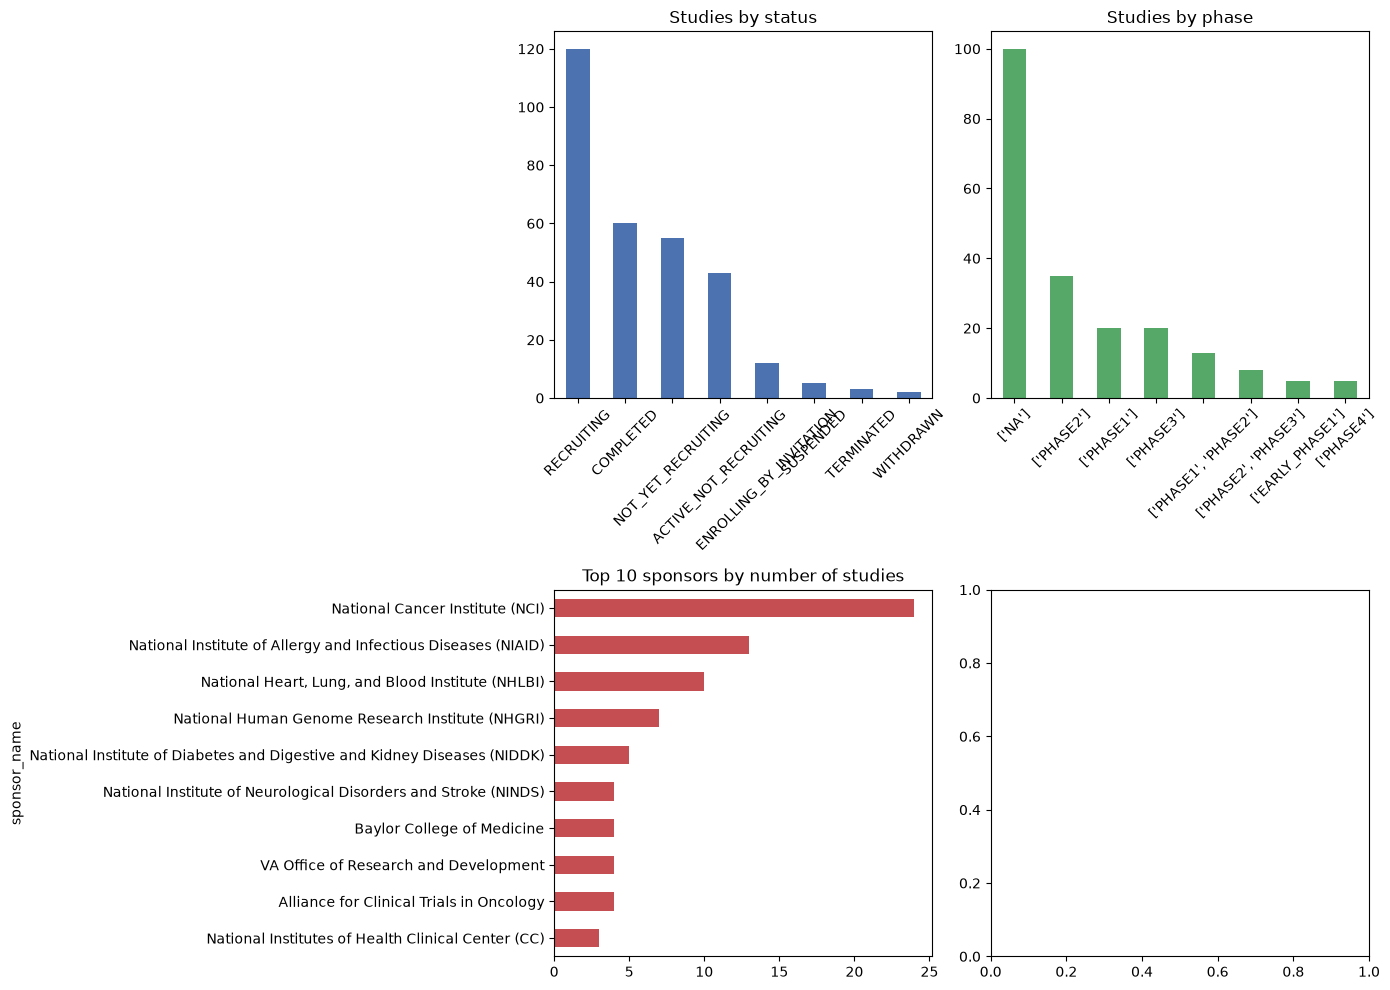

In [35]:
# ============================================================
# CHARTS - Gold layer visualization
# ============================================================

import matplotlib.pyplot as plt

def _load_gold_as_pandas(table_name: str):
    path = f'{CONFIG["gold_base_path"]}/{table_name}'
    if not os.path.exists(path):
        return None
    rows = [row.asDict(recursive=True) for row in spark.read.format("delta").load(path).collect()]
    return pd.DataFrame(rows)

df_dim_study = _load_gold_as_pandas("dim_study")
df_dim_sponsor = _load_gold_as_pandas("dim_sponsor")
df_fact_study = _load_gold_as_pandas("fact_study")
df_fact_ae = _load_gold_as_pandas("fact_adverse_event")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Studies by status (overall_status)
if df_dim_study is not None and "overall_status" in df_dim_study.columns:
    df_dim_study["overall_status"].value_counts().plot(kind="bar", ax=axes[0, 0], color="#4C72B0")
    axes[0, 0].set_title("Studies by status")
    axes[0, 0].set_xlabel("")
    axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Studies by phase
if df_dim_study is not None and "phases" in df_dim_study.columns:
    df_dim_study["phases"].astype(str).value_counts().plot(kind="bar", ax=axes[0, 1], color="#55A868")
    axes[0, 1].set_title("Studies by phase")
    axes[0, 1].set_xlabel("")
    axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Top 10 sponsors by number of studies
if df_fact_study is not None and df_dim_sponsor is not None and "sponsor_id" in df_fact_study.columns:
    top_sponsors = df_fact_study.merge(df_dim_sponsor, on="sponsor_id", how="left") \
        ["sponsor_name"].value_counts().head(10)
    top_sponsors.plot(kind="barh", ax=axes[1, 0], color="#C44E52")
    axes[1, 0].set_title("Top 10 sponsors by number of studies")
    axes[1, 0].invert_yaxis()

# 4. Top 10 drugs by adverse events
if df_fact_ae is not None and "drug_id" in df_fact_ae.columns:
    df_fact_ae["drug_id"].value_counts().head(10).plot(kind="bar", ax=axes[1, 1], color="#8172B2")
    axes[1, 1].set_title("Top 10 drugs by reported adverse events")
    axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [36]:
!pip install azure-storage-file-datalake azure-identity python-dotenv

IOStream.flush timed out
